#  Hollow Knight Universe — GraphRAG Projesi

**Amaç:** Hollow Knight + Silksong wiki verisinden bir Knowledge Graph oluşturup, GNN + RAG ile akıllı soru-cevap sistemi kurmak.

###  Notebook Planı
1. **Bölüm 1** — Kütüphaneler & Kurulum
2. **Bölüm 2** — Wiki'den Veri Çekme (Scraping)
3. **Bölüm 3** — Entity & Relation Çıkarma
4. **Bölüm 4** — Knowledge Graph Oluşturma & Görselleştirme
5. **Bölüm 5** — GNN ile Node Embedding & Link Prediction
6. **Bölüm 6** — RAG Pipeline (Vektör + Graf Arama)
7. **İyileştirmeler** — Entity Classification + Semantic Relations
8. **Demo** — İnteraktif Chat Arayüzü

---

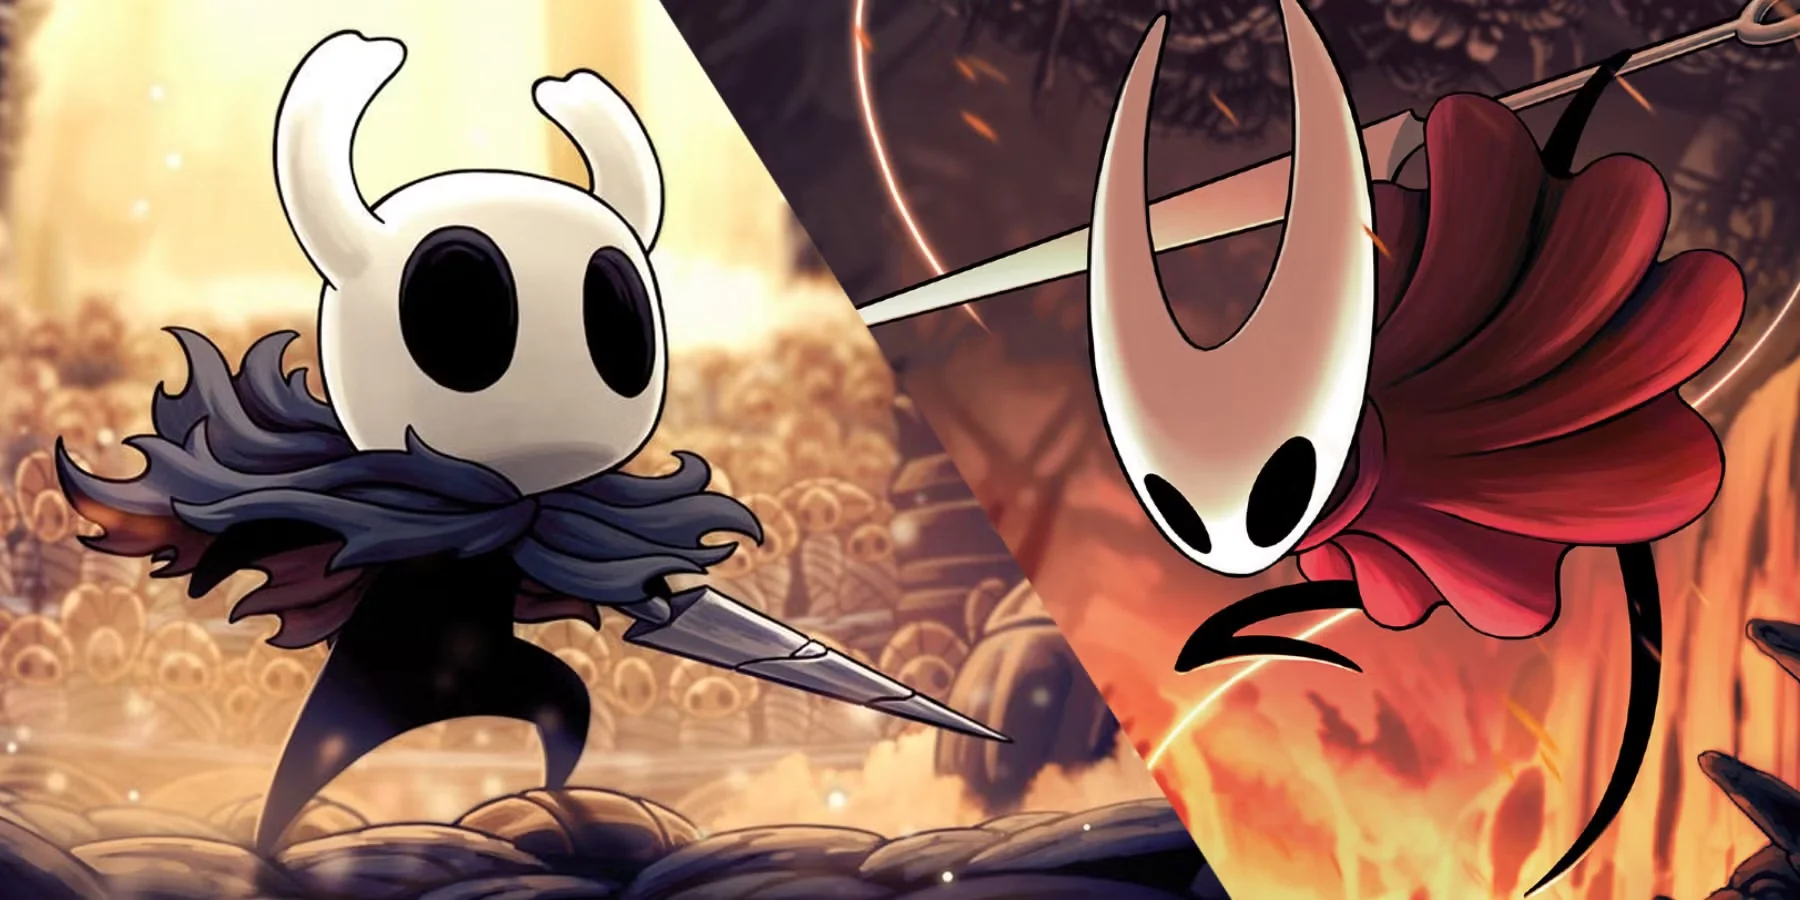

##  Bölüm 1 — Kurulum
İlk çalıştırmada tüm bağımlılıkları yükler.

In [ ]:
# 1.1 — Kütüphaneleri Yükle
!pip install -q --upgrade transformers
!pip install -q \
    requests beautifulsoup4 tqdm \
    torch torch-geometric \
    sentence-transformers chromadb \
    networkx pyvis matplotlib \
    accelerate bitsandbytes huggingface_hub \
    pandas numpy scikit-learn

print(" Tüm kütüphaneler yüklendi!")

In [ ]:
# 1.2 — Import'lar

import requests
import json
import time
import re
import os
import pickle
from pathlib import Path
from bs4 import BeautifulSoup
from urllib.parse import quote, unquote
from tqdm.notebook import tqdm
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Klasör yapısı
DATA_DIR = Path("data")
PAGES_DIR = DATA_DIR / "pages"
PAGES_DIR.mkdir(parents=True, exist_ok=True)

print(" Import'lar hazır.")

---
##  Bölüm 2 — Wiki'den Veri Çekme

hollowknight.wiki'deki **tüm sayfaları** çekiyoruz — hem Hollow Knight hem Silksong. Veriler Google Drive'a kaydedilir.

In [ ]:
#2.1- MediaWiki API ile Tüm sayfa Listesi

BASE_URL = "https://hollowknight.wiki"
API_URL = f"{BASE_URL}/mw/api.php"
HEADERS = {"User-Agent": "HollowKnightGraphRAG-StudentProject/1.0 (academic research)"}
DELAY = 1.0

def get_all_page_titles():
    """MediaWiki API'den tüm sayfa başlıklarını çeker."""
    all_titles = []
    params = {
        "action": "query",
        "list": "allpages",
        "aplimit": 500,
        "format": "json",
    }
    while True:
        resp = requests.get(API_URL, params=params, headers=HEADERS, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        pages = data.get("query", {}).get("allpages", [])
        all_titles.extend([p["title"] for p in pages])
        if "continue" in data:
            params["apcontinue"] = data["continue"]["apcontinue"]
            time.sleep(DELAY)
        else:
            break
    return all_titles

print("Sayfa listesi çekiliyor...")
all_titles = get_all_page_titles()
print(f"Toplam {len(all_titles)} sayfa bulundu")
print(f"\nİlk 20 sayfa: {all_titles[:20]}")

In [ ]:
# 2.2 — Sayfa İçeriklerini Çek (Google Drive'a kaydet)

from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/GraphRAG"
os.makedirs(SAVE_DIR, exist_ok=True)
DRIVE_CACHE = f"{SAVE_DIR}/pages_data.json"

def fetch_page_content(title):
    """Tek bir sayfanın parse edilmiş içeriğini API ile çeker."""
    params = {
        "action": "parse",
        "page": title,
        "prop": "text|links|categories|sections",
        "format": "json",
    }
    try:
        resp = requests.get(API_URL, params=params, headers=HEADERS, timeout=30)
        data = resp.json()
        if "error" in data:
            return None

        parse = data["parse"]
        html = parse.get("text", {}).get("*", "")

        soup = BeautifulSoup(html, "html.parser")
        for tag in soup.find_all(["script", "style"]):
            tag.decompose()
        text = soup.get_text(separator="\n", strip=True)

        tables = []
        for table in soup.find_all("table", {"class": "wikitable"}):
            rows = []
            for tr in table.find_all("tr"):
                cells = [td.get_text(strip=True) for td in tr.find_all(["td", "th"])]
                if cells:
                    rows.append(cells)
            if rows:
                tables.append(rows)

        links = [l["*"] for l in parse.get("links", []) if l.get("exists") is not None]
        categories = [c["*"] for c in parse.get("categories", [])]
        sections = [s["line"] for s in parse.get("sections", [])]

        return {
            "title": title,
            "text": text,
            "internal_links": links,
            "categories": categories,
            "sections": sections,
            "tables": tables,
        }
    except Exception as e:
        print(f"   {title}: {e}")
        return None


# Drive'da veri var mı kontrol et
if os.path.exists(DRIVE_CACHE):
    with open(DRIVE_CACHE, "r", encoding="utf-8") as f:
        pages_data = json.load(f)
    print(f" Drive'dan {len(pages_data)} sayfa yüklendi.")
else:
    pages_data = {}
    print(" Drive'da veri yok, sıfırdan çekiliyor.")

# Eksik sayfaları çek
missing = [t for t in all_titles if t not in pages_data]
if missing:
    print(f" {len(missing)} sayfa çekiliyor...")
    for title in tqdm(missing, desc="Sayfalar"):
        content = fetch_page_content(title)
        if content and len(content["text"]) > 10:
            pages_data[title] = content
        time.sleep(DELAY)

    # Drive'a kaydet
    with open(DRIVE_CACHE, "w", encoding="utf-8") as f:
        json.dump(pages_data, f, ensure_ascii=False)
    print(f" Drive'a kaydedildi!")
else:
    print(" Tüm sayfalar mevcut.")

print(f"\n Toplam sayfa: {len(pages_data)}")
print(f" Toplam metin: {sum(len(p['text']) for p in pages_data.values()):,} karakter")
print(f" Toplam dahili link: {sum(len(p['internal_links']) for p in pages_data.values()):,}")

In [ ]:
# 2.3 — Veri Kalitesini Kontrol Et
# Rastgele bir sayfanın içeriğine bakalım

import random

sample_key = random.choice(list(pages_data.keys()))
sample = pages_data[sample_key]

print(f"\n Toplam sayfa: {len(pages_data)}")
print(f" Sayfa: {sample['title']}")
print(f" Metin uzunluğu: {len(sample['text'])} karakter")
print(f" Dahili link sayısı: {len(sample['internal_links'])}")
print(f" Kategoriler: {sample['categories']}")
print(f" Bölümler: {sample['sections']}")
print(f"\n--- METİN ÖNİZLEME (ilk 500 karakter) ---")
print(sample["text"][:500])

---
##  Bölüm 3 — Entity & Relation Çıkarma

Wiki'deki dahili linkler zaten bize doğal bir entity-relation yapısı veriyor. Bunu zenginleştireceğiz:
1. **Link-based relations** — sayfa A, sayfa B'ye link veriyorsa → ilişki var
2. **Category-based typing** — sayfa kategorisinden entity tipini çıkar
3. **Pattern-based relations** — metin içi kalıplardan ("located in", "drops", "requires") ilişki çıkar

In [ ]:
# 3.1 — Entity Tipleri Belirleme

# Kategori → Entity tipi eşlemesi
CATEGORY_TO_TYPE = {
    "boss": ["Bosses", "Boss"],
    "enemy": ["Enemies", "Enemy"],
    "npc": ["NPCs", "NPC", "Characters"],
    "area": ["Areas", "Locations", "Pharloom", "Sub-areas", "Hallownest"],
    "skill": ["Skills", "Abilities", "Spells", "Nail Arts", "Ancestral Arts"],
    "item": ["Items", "Tools", "Equipment", "Charms", "Relics", "Key Items"],
    "quest": ["Quests", "Quest"],
    "lore": ["Lore", "Lore Tablets"],
    "mechanic": ["Mechanics", "Gameplay"],
}

def classify_entity(page):
    """Sayfanın kategorilerinden entity tipini belirle."""
    cats = " ".join(page.get("categories", [])).lower()
    title = page["title"].lower()

    for etype, keywords in CATEGORY_TO_TYPE.items():
        if any(kw.lower() in cats or kw.lower() in title for kw in keywords):
            return etype
    return "other"


# Her sayfayı entity olarak kaydet
entities = {}
for title, page in pages_data.items():
    entities[title] = {
        "type": classify_entity(page),
        "categories": page.get("categories", []),
        "text_length": len(page["text"]),
        "link_count": len(page.get("internal_links", [])),
    }

# Tip dağılımı
type_counts = Counter(e["type"] for e in entities.values())
print(" Entity Tip Dağılımı:")
for etype, count in type_counts.most_common():
    print(f"  {etype:12s} → {count}")
print(f"\n  TOPLAM: {len(entities)}")

In [ ]:
# 3.2 — Relation Çıkarma

relations = []

# --- A) Link-based relations ---
for title, page in pages_data.items():
    for link in page.get("internal_links", []):
        if link in pages_data:  # Sadece var olan sayfalara
            relations.append({
                "source": title,
                "target": link,
                "relation": "REFERENCES",
            })

#  B) Pattern-based relations
PATTERNS = [
    (r"(?:located|found|situated)\s+in\s+(?:the\s+)?([A-Z][\w\s']+?)[\.\,]", "LOCATED_IN"),
    (r"(?:drops?|rewards?)\s+(?:the\s+)?([A-Z][\w\s']+?)[\.\,]", "DROPS"),
    (r"(?:requires?|needs?)\s+(?:the\s+)?([A-Z][\w\s']+?)[\.\,]", "REQUIRES"),
    (r"(?:unlocks?|opens?)\s+(?:the\s+)?([A-Z][\w\s']+?)[\.\,]", "UNLOCKS"),
    (r"(?:leads?|connects?)\s+to\s+(?:the\s+)?([A-Z][\w\s']+?)[\.\,]", "CONNECTS_TO"),
    (r"(?:guards?|protects?|blocks?)\s+(?:the\s+)?([A-Z][\w\s']+?)[\.\,]", "GUARDS"),
    (r"(?:sells?|offers?)\s+(?:the\s+)?([A-Z][\w\s']+?)[\.\,]", "SELLS"),
    (r"(?:gives?|grants?)\s+(?:the\s+)?([A-Z][\w\s']+?)[\.\,]", "GIVES"),
    (r"(?:defeated|killed)\s+by\s+(?:the\s+)?([A-Z][\w\s']+?)[\.\,]", "DEFEATED_BY"),
    (r"(?:part|member)\s+of\s+(?:the\s+)?([A-Z][\w\s']+?)[\.\,]", "PART_OF"),
]

for title, page in pages_data.items():
    text = page["text"]
    for pattern, rel_type in PATTERNS:
        matches = re.findall(pattern, text)
        for match in matches[:5]:  # Gürültüyü sınırla
            match = match.strip()
            if 3 < len(match) < 60:
                # Eşleşmeyi mevcut entity'lerle bağla
                matched_entity = None
                for ent_name in pages_data:
                    if match.lower() in ent_name.lower().replace("_", " "):
                        matched_entity = ent_name
                        break

                target = matched_entity if matched_entity else match
                relations.append({
                    "source": title,
                    "target": target,
                    "relation": rel_type,
                })

# Duplicat'ları temizle
seen = set()
unique_relations = []
for r in relations:
    key = (r["source"], r["relation"], r["target"])
    if key not in seen:
        seen.add(key)
        unique_relations.append(r)
relations = unique_relations

# İstatistikler
rel_counts = Counter(r["relation"] for r in relations)
print(f" Toplam unique relation: {len(relations)}")
print("\nRelation Tip Dağılımı:")
for rtype, count in rel_counts.most_common():
    print(f"  {rtype:15s} → {count}")

In [ ]:
# 3.3 — Verileri Kaydet

# Entity ve relation verilerini JSON olarak kaydet
kg_data = {
    "entities": entities,
    "relations": relations,
    "stats": {
        "total_entities": len(entities),
        "total_relations": len(relations),
        "entity_types": dict(type_counts),
        "relation_types": dict(rel_counts),
    }
}

with open(DATA_DIR / "knowledge_graph.json", "w", encoding="utf-8") as f:
    json.dump(kg_data, f, ensure_ascii=False, indent=2)

print(" knowledge_graph.json kaydedildi.")
print(json.dumps(kg_data["stats"], indent=2))

---
##  Bölüm 4 — Knowledge Graph Oluşturma & Görselleştirme

NetworkX ile grafı oluşturup, PyVis ile interaktif görselleştirme yapacağız.

In [ ]:
# 4.1 — NetworkX Grafı Oluştur

G = nx.DiGraph()

# Düğümleri ekle
for name, info in entities.items():
    G.add_node(name, **info)

# Kenarları ekle
for rel in relations:
    src, tgt = rel["source"], rel["target"]
    if src in G.nodes and tgt in G.nodes:
        G.add_edge(src, tgt, relation=rel["relation"])

print(f" Graf İstatistikleri:")
print(f"  Düğüm sayısı:  {G.number_of_nodes()}")
print(f"  Kenar sayısı:  {G.number_of_edges()}")
print(f"  Yoğunluk:     {nx.density(G):.4f}")

# Bağlantılılık
if nx.is_weakly_connected(G):
    print("Bağlantılılık: Weakly connected")
else:
    components = list(nx.weakly_connected_components(G))
    print(f"  Bileşen sayısı: {len(components)}")
    print(f"  En büyük bileşen: {len(max(components, key=len))} düğüm")

# En merkezi düğümler (PageRank)
pr = nx.pagerank(G)
top_nodes = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10]
print(f"\n En Merkezi 10 Düğüm (PageRank):")
for name, score in top_nodes:
    print(f"  {name:30s} → {score:.4f}  [{entities.get(name, {}).get('type', '?')}]")

In [ ]:
# 4.2 — Tip Bazlı İstatistik Grafik

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Entity dağılımı
types, counts = zip(*type_counts.most_common())
colors = plt.cm.Set3(np.linspace(0, 1, len(types)))
axes[0].barh(types, counts, color=colors)
axes[0].set_title("Entity Tip Dağılımı", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Sayı")

# Relation dağılımı
rtypes, rcounts = zip(*rel_counts.most_common(10))
axes[1].barh(rtypes, rcounts, color=plt.cm.Paired(np.linspace(0, 1, len(rtypes))))
axes[1].set_title("İlişki Tip Dağılımı (Top 10)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Sayı")

plt.tight_layout()
plt.savefig(DATA_DIR / "kg_statistics.png", dpi=150, bbox_inches="tight")
plt.show()
print(" kg_statistics.png kaydedildi.")

In [ ]:
# 4.3 — İnteraktif Graf Görselleştirme (PyVis)

from pyvis.network import Network

# Büyük grafı alt küme ile görselleştir (tamamı çok yoğun olur)
# En merkezi 80 düğümü al
top_n = 80
top_node_names = [n for n, _ in sorted(pr.items(), key=lambda x: x[1], reverse=True)[:top_n]]
subG = G.subgraph(top_node_names).copy()

# Tip -> renk eşlemesi
TYPE_COLORS = {
    "boss": "#e74c3c",
    "enemy": "#e67e22",
    "npc": "#2ecc71",
    "area": "#3498db",
    "skill": "#9b59b6",
    "item": "#f1c40f",
    "quest": "#1abc9c",
    "lore": "#95a5a6",
    "mechanic": "#34495e",
    "other": "#bdc3c7",
}

net = Network(height="700px", width="100%", notebook=True, directed=True)
net.barnes_hut(gravity=-5000, spring_length=150)

for node in subG.nodes(data=True):
    name = node[0]
    etype = node[1].get("type", "other")
    size = 10 + pr.get(name, 0) * 3000
    net.add_node(
        name,
        label=name.replace("_", " "),
        color=TYPE_COLORS.get(etype, "#bdc3c7"),
        size=size,
        title=f"{name}\nTip: {etype}\nPageRank: {pr.get(name, 0):.4f}",
    )

for u, v, data in subG.edges(data=True):
    net.add_edge(u, v, title=data.get("relation", ""), arrows="to")

net.show(str(DATA_DIR / "knowledge_graph.html"))
print(" İnteraktif graf: data/knowledge_graph.html")

#Colab'da sol panelden dosya indirilip tarayıcıda açılabilir.

---
##  Bölüm 5 — GNN ile Node Embedding & Link Prediction

PyTorch Geometric kullanarak:
1. Graf verisini PyG formatına dönüştür
2. GAT (Graph Attention Network) ile node embedding öğren
3. Link prediction görevi ile değerlendir

In [ ]:
# 5.1 — Grafı PyG Formatına Dönüştür

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.utils import negative_sampling
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device: {device}")

# Düğümleri indeksle
node_list = list(G.nodes())
node_to_idx = {n: i for i, n in enumerate(node_list)}
num_nodes = len(node_list)

# Kenarları tensor'a çevir
edge_list = [(node_to_idx[u], node_to_idx[v])
             for u, v in G.edges()
             if u in node_to_idx and v in node_to_idx]
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

# Node feature: entity tipini one-hot encode et
all_types = sorted(set(entities.get(n, {}).get("type", "other") for n in node_list))
type_to_idx = {t: i for i, t in enumerate(all_types)}
num_types = len(all_types)

x = torch.zeros(num_nodes, num_types)
for i, node in enumerate(node_list):
    etype = entities.get(node, {}).get("type", "other")
    x[i, type_to_idx[etype]] = 1.0

# PyG Data nesnesi
data = Data(x=x, edge_index=edge_index).to(device)

print(f"\n PyG Data:")
print(f"  Düğüm sayısı:   {data.num_nodes}")
print(f"  Kenar sayısı:    {data.num_edges}")
print(f"  Feature boyutu:  {data.num_node_features}")
print(f"  Tip kategorileri: {all_types}")

In [ ]:
# 5.2 — Train/Val/Test Split (Link Prediction)

from torch_geometric.transforms import RandomLinkSplit

transform = RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    is_undirected=False,
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0,
)

train_data, val_data, test_data = transform(data)

print(f" Link Split:")
print(f"  Train kenarları: {train_data.edge_label.sum().int().item()} pozitif")
print(f"  Val kenarları:   {val_data.edge_label.sum().int().item()} pozitif")
print(f"  Test kenarları:  {test_data.edge_label.sum().int().item()} pozitif")

In [ ]:
# 5.3 — GNN Modeli (GCN + GAT seçenekli)

from torch_geometric.nn import GCNConv, GATConv

class SilksongGNN(torch.nn.Module):
    """Link Prediction için GNN modeli."""

    def __init__(self, in_channels, hidden_channels, out_channels, model_type="GCN"):
        super().__init__()
        self.model_type = model_type

        if model_type == "GCN":
            self.conv1 = GCNConv(in_channels, hidden_channels)
            self.conv2 = GCNConv(hidden_channels, out_channels)
        elif model_type == "GAT":
            self.conv1 = GATConv(in_channels, hidden_channels, heads=4, concat=True)
            self.conv2 = GATConv(hidden_channels * 4, out_channels, heads=1, concat=False)

        self.dropout = torch.nn.Dropout(0.3)

    def encode(self, x, edge_index):
        """Node embedding üret."""
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        """İki düğüm arasındaki link olasılığını hesapla."""
        src = z[edge_label_index[0]]
        dst = z[edge_label_index[1]]
        return (src * dst).sum(dim=-1)

    def forward(self, x, edge_index, edge_label_index):
        z = self.encode(x, edge_index)
        return self.decode(z, edge_label_index)


# Model oluştur
HIDDEN_DIM = 64
EMBED_DIM = 32
MODEL_TYPE = "GAT"  # "GCN" veya "GAT"

model = SilksongGNN(
    in_channels=num_types,
    hidden_channels=HIDDEN_DIM,
    out_channels=EMBED_DIM,
    model_type=MODEL_TYPE,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.BCEWithLogitsLoss()

print(f" Model: {MODEL_TYPE}")
print(f"  Parametreler: {sum(p.numel() for p in model.parameters()):,}")
print(model)

In [ ]:
# 5.4 — Eğitim Döngüsü

from sklearn.metrics import roc_auc_score, average_precision_score

def train_epoch():
    model.train()
    optimizer.zero_grad()
    out = model(train_data.x, train_data.edge_index, train_data.edge_label_index)
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(split_data):
    model.eval()
    out = model(split_data.x, split_data.edge_index, split_data.edge_label_index)
    probs = torch.sigmoid(out).cpu().numpy()
    labels = split_data.edge_label.cpu().numpy()
    auc = roc_auc_score(labels, probs)
    ap = average_precision_score(labels, probs)
    return auc, ap


# Eğitim
EPOCHS = 200
best_val_auc = 0
history = {"loss": [], "val_auc": [], "val_ap": []}

print(f" Eğitim başlıyor ({EPOCHS} epoch)...\n")
for epoch in range(1, EPOCHS + 1):
    loss = train_epoch()
    val_auc, val_ap = evaluate(val_data)

    history["loss"].append(loss)
    history["val_auc"].append(val_auc)
    history["val_ap"].append(val_ap)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), DATA_DIR / "best_gnn.pt")

    if epoch % 20 == 0:
        print(f"  Epoch {epoch:3d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")

# Test sonucu
model.load_state_dict(torch.load(DATA_DIR / "best_gnn.pt"))
test_auc, test_ap = evaluate(test_data)
print(f"\n Test Sonuçları:")
print(f"  AUC:  {test_auc:.4f}")
print(f"  AP:   {test_ap:.4f}")

In [ ]:
# 5.5 — Eğitim Grafikleri

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history["loss"], color="#e74c3c", linewidth=1.5)
axes[0].set_title("Training Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(history["val_auc"], label="AUC", color="#3498db", linewidth=1.5)
axes[1].plot(history["val_ap"], label="AP", color="#2ecc71", linewidth=1.5)
axes[1].set_title("Validation Metrics", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# 5.6 — Node Embedding'leri Çıkar ve Kaydet

model.eval()
with torch.no_grad():
    embeddings = model.encode(data.x, data.edge_index).cpu().numpy()

# Embedding'leri dict olarak kaydet
node_embeddings = {node_list[i]: embeddings[i].tolist() for i in range(num_nodes)}

with open(DATA_DIR / "node_embeddings.json", "w") as f:
    json.dump(node_embeddings, f)

print(f" {len(node_embeddings)} node embedding kaydedildi.")
print(f"  Embedding boyutu: {embeddings.shape[1]}")

# t-SNE görselleştirme
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, num_nodes - 1))
coords = tsne.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
for etype in all_types:
    mask = [entities.get(n, {}).get("type", "other") == etype for n in node_list]
    plt.scatter(
        coords[mask, 0], coords[mask, 1],
        label=etype, alpha=0.6, s=20,
    )
plt.legend(loc="best", fontsize=9)
plt.title("GNN Node Embeddings (t-SNE)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig(DATA_DIR / "tsne_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()

---
##  Bölüm 6 — GraphRAG Pipeline

Üç retriever birleştiriyoruz:
1. **Entity Arama** — graf'tan bulunan entity'lerin tam wiki sayfaları
2. **Vektör Arama** — sayfa metinlerinden embedding + ChromaDB
3. **Graf Arama** — bilgi grafiğinden komşuluk ilişkileri

LLM bu üç kaynağı birleştirerek cevap üretir.

In [ ]:
# 6.1 — Metin Chunk'lama & Vektör DB

from sentence_transformers import SentenceTransformer
import chromadb

# Embedding modeli
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

def chunk_text(text, chunk_size=500, overlap=100):
    """Metni örtüşen parçalara böl."""
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size - overlap):
        chunk = " ".join(words[i:i + chunk_size])
        if len(chunk) > 50:
            chunks.append(chunk)
    return chunks


# Tüm sayfaları chunk'la
all_chunks = []
chunk_metadata = []

for title, page in tqdm(pages_data.items(), desc="Chunk'lama"):
    chunks = chunk_text(page["text"])
    for i, chunk in enumerate(chunks):
        all_chunks.append(chunk)
        chunk_metadata.append({
            "page": title,
            "chunk_idx": i,
            "entity_type": entities.get(title, {}).get("type", "other"),
        })

print(f" Toplam chunk: {len(all_chunks)}")

# ChromaDB'ye yükle
client = chromadb.Client()
collection = client.create_collection("hollowknight_wiki")

# Batch halinde embedding + yükleme
BATCH = 100
for i in tqdm(range(0, len(all_chunks), BATCH), desc="Vektör DB"):
    batch_chunks = all_chunks[i:i+BATCH]
    batch_meta = chunk_metadata[i:i+BATCH]
    batch_ids = [f"chunk_{j}" for j in range(i, i+len(batch_chunks))]

    embeddings = embed_model.encode(batch_chunks).tolist()

    collection.add(
        documents=batch_chunks,
        embeddings=embeddings,
        metadatas=batch_meta,
        ids=batch_ids,
    )

print(f" ChromaDB'ye {collection.count()} chunk yüklendi.")

In [ ]:
# 6.2 — Graf Arama Fonksiyonları

def graph_search(query_entity, hops=2):
    """
    Bir entity'nin komşuluğunu graf üzerinde keşfeder.
    hops: kaç adım komşuluk genişletilecek.
    """
    if query_entity not in G:
        # Fuzzy matching dene
        matches = [n for n in G.nodes if query_entity.lower() in n.lower()]
        if not matches:
            return {"nodes": [], "edges": [], "paths": []}
        query_entity = matches[0]

    # BFS ile komşuluk
    visited = {query_entity}
    frontier = [query_entity]
    result_nodes = []
    result_edges = []

    for hop in range(hops):
        next_frontier = []
        for node in frontier:
            for neighbor in list(G.successors(node)) + list(G.predecessors(node)):
                edge_data = G.get_edge_data(node, neighbor) or G.get_edge_data(neighbor, node)
                rel = edge_data.get("relation", "RELATED") if edge_data else "RELATED"

                result_edges.append({
                    "source": node,
                    "target": neighbor,
                    "relation": rel,
                    "hop": hop + 1,
                })

                if neighbor not in visited:
                    visited.add(neighbor)
                    next_frontier.append(neighbor)
                    etype = entities.get(neighbor, {}).get("type", "other")
                    result_nodes.append({"name": neighbor, "type": etype, "hop": hop + 1})

        frontier = next_frontier

    return {"center": query_entity, "nodes": result_nodes, "edges": result_edges}


def find_path(source, target):
    """İki entity arasındaki en kısa yolu bulur."""
    # Fuzzy match
    src_matches = [n for n in G.nodes if source.lower() in n.lower()]
    tgt_matches = [n for n in G.nodes if target.lower() in n.lower()]

    if not src_matches or not tgt_matches:
        return None

    try:
        path = nx.shortest_path(G, src_matches[0], tgt_matches[0])
        path_details = []
        for i, node in enumerate(path):
            etype = entities.get(node, {}).get("type", "other")
            detail = {"node": node, "type": etype, "step": i}
            if i > 0:
                edge = G.get_edge_data(path[i-1], node)
                detail["relation"] = edge.get("relation", "RELATED") if edge else "RELATED"
            path_details.append(detail)
        return path_details
    except nx.NetworkXNoPath:
        return None


# Test
print(" Graf Arama Testi:")
test_result = graph_search("Hornet", hops=1)
print(f"  Merkez: {test_result.get('center', 'N/A')}")
print(f"  Komşu sayısı: {len(test_result['nodes'])}")
if test_result['nodes']:
    print(f"  İlk 5 komşu: {[n['name'] for n in test_result['nodes'][:5]]}")

In [ ]:
# 6.3a — LLM Yükleme (Gemma 4)

!pip install -q git+https://github.com/huggingface/transformers.git

login(token=userdata.get("HF_TOKEN"))
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

MODEL_ID = "google/gemma-4-E4B-it"

print(f" {MODEL_ID} yükleniyor...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
llm_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device_map="auto",
)
print("Gemma 4 hazır!")

In [ ]:
# İYİLEŞTİRME 1: Entity Classification

MANUAL_TYPES = {
    "Hollow Knight: Silksong": "mechanic",
    "Hollow Knight": "mechanic",
    "The Knight": "npc",
    "Hornet": "npc",
    "Hornet (Silksong)": "npc",
    "Hornet (Hollow Knight)": "boss",
    "Hollow Knight Kickstarter": "lore",
    "Godmaster": "lore",
    "The Grimm Troupe": "lore",
    "Pharloom": "area",
    "Hallownest": "area",
    "The Hollow Knight": "boss",
    "Pale King": "npc",
    "White Lady": "npc",
    "Herrah": "npc",
    "Grimm": "boss",
    "Radiance": "boss",
}

def smart_classify(title, page):
    if title in MANUAL_TYPES:
        return MANUAL_TYPES[title]

    cats = " ".join(page.get("categories", [])).lower()
    text_lower = page["text"][:500].lower()

    if any(kw in cats for kw in ["boss", "bos"]):
        return "boss"
    if any(kw in cats for kw in ["enem", "creature", "beast"]):
        return "enemy"
    if any(kw in cats for kw in ["npc", "character", "individual"]):
        return "npc"
    if any(kw in cats for kw in ["area", "location", "sub-area", "region"]):
        return "area"
    if any(kw in cats for kw in ["skill", "abilit", "spell", "art"]):
        return "skill"
    if any(kw in cats for kw in ["item", "tool", "charm", "equip", "relic"]):
        return "item"
    if any(kw in cats for kw in ["quest"]):
        return "quest"
    if any(kw in cats for kw in ["lore", "tablet"]):
        return "lore"

    if any(kw in text_lower for kw in ["is a boss", "boss fight", "boss in"]):
        return "boss"
    if any(kw in text_lower for kw in ["is an enemy", "enemies in", "creature found"]):
        return "enemy"
    if any(kw in text_lower for kw in ["is an npc", "is a character", "can be found sitting", "dialogue"]):
        return "npc"
    if any(kw in text_lower for kw in ["is an area", "is a sub-area", "region in", "located in"]):
        return "area"
    if any(kw in text_lower for kw in ["is a skill", "is an ability", "can be unlocked"]):
        return "skill"
    if any(kw in text_lower for kw in ["is an item", "is a tool", "is a charm", "can be equipped"]):
        return "item"
    if any(kw in text_lower for kw in ["is a quest", "quest in"]):
        return "quest"

    if "(Silksong)" in title or "(Hollow Knight)" in title:
        base = title.split("(")[0].strip()
        if base in entities and entities[base]["type"] != "other":
            return entities[base]["type"]

    return "other"

old_other = sum(1 for e in entities.values() if e["type"] == "other")
for title, page in pages_data.items():
    if title in entities:
        entities[title]["type"] = smart_classify(title, page)

for node in G.nodes:
    if node in entities:
        G.nodes[node]["type"] = entities[node]["type"]

new_other = sum(1 for e in entities.values() if e["type"] == "other")
type_counts_new = Counter(e["type"] for e in entities.values())

print(f" Entity Classification güncellendi!")
print(f"   'other' tipi: {old_other} → {new_other}")
print(f"\n Yeni Dağılım:")
for etype, count in type_counts_new.most_common():
    print(f"   {etype:12s} → {count}")

In [ ]:
# İYİLEŞTİRME 2: Semantic Relation Extraction

SEMANTIC_PATTERNS = [
    (r"(?:child|offspring|daughter|son) of (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "CHILD_OF"),
    (r"(?:parent|father|mother) of (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "PARENT_OF"),
    (r"(?:sibling|sister|brother) of (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "SIBLING_OF"),
    (r"(?:created|made) by (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "CREATED_BY"),
    (r"(?:serves?|servant of|loyal to) (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "SERVES"),
    (r"(?:found|located|situated|resides?) in (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "LOCATED_IN"),
    (r"(?:leads?|connects?|passage) to (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "CONNECTS_TO"),
    (r"(?:entrance|gateway|door) to (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "GATEWAY_TO"),
    (r"(?:sub-area|part) of (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "PART_OF"),
    (r"(?:borders?|adjacent to) (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "BORDERS"),
    (r"(?:drops?|rewards?) (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "DROPS"),
    (r"(?:requires?|needs?|must have) (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "REQUIRES"),
    (r"(?:unlocks?|opens?|grants? access) (?:the |to (?:the )?)?([A-Z][\w\s']+?)[\.\,\;]", "UNLOCKS"),
    (r"(?:sells?|offers?) (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "SELLS"),
    (r"(?:guards?|protects?|blocks?) (?:the |access to (?:the )?)?([A-Z][\w\s']+?)[\.\,\;]", "GUARDS"),
    (r"(?:teaches?|gives?) (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "GIVES"),
    (r"(?:weak|vulnerable) to (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "WEAK_TO"),
    (r"(?:defeated|killed|slain) by (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "DEFEATED_BY"),
    (r"(?:boss|guardian|protector) of (?:the )?([A-Z][\w\s']+?)[\.\,\;]", "BOSS_OF"),
]

entity_names_lower = {name.lower().replace("_", " "): name for name in pages_data}

def match_to_entity(text_match):
    match_lower = text_match.strip().lower()
    if match_lower in entity_names_lower:
        return entity_names_lower[match_lower]
    for ent_lower, ent_name in entity_names_lower.items():
        if match_lower in ent_lower or ent_lower in match_lower:
            return ent_name
    return None

new_relations = []
for title, page in tqdm(pages_data.items(), desc="Semantic Relations"):
    text = page["text"]
    for pattern, rel_type in SEMANTIC_PATTERNS:
        matches = re.findall(pattern, text)
        for match in matches[:8]:
            match = match.strip()
            if 2 < len(match) < 80:
                target = match_to_entity(match)
                if target and target != title:
                    new_relations.append({
                        "source": title,
                        "target": target,
                        "relation": rel_type,
                    })

semantic_seen = set()
semantic_relations = []
for r in new_relations:
    key = (r["source"], r["relation"], r["target"])
    if key not in semantic_seen:
        semantic_seen.add(key)
        semantic_relations.append(r)

added = 0
for rel in semantic_relations:
    src, tgt = rel["source"], rel["target"]
    if src in G.nodes and tgt in G.nodes:
        G.add_edge(src, tgt, relation=rel["relation"])
        added += 1

sem_counts = Counter(r["relation"] for r in semantic_relations)
print(f"\n {len(semantic_relations)} yeni semantic relation çıkarıldı!")
print(f"   Grafa {added} kenar eklendi.")
print(f"\n Yeni Relation Dağılımı:")
for rtype, count in sem_counts.most_common(15):
    print(f"   {rtype:15s} → {count}")

relations.extend(semantic_relations)
print(f"\n   Toplam kenar: {G.number_of_edges()}")

In [ ]:
# 6.3b — GraphRAG: Dual Retriever + LLM

def generate_answer(prompt, max_new_tokens=1024):
    messages=[{"role":"user","content":prompt}]
    input_text=tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=True)
    inputs=tokenizer(input_text,return_tensors="pt").to(llm_model.device)
    with torch.no_grad():
        output=llm_model.generate(**inputs,max_new_tokens=max_new_tokens,temperature=0.7,do_sample=True)
    return tokenizer.decode(output[0][inputs["input_ids"].shape[1]:],skip_special_tokens=True)


def graphrag_retrieve(question, top_k_vector=8, graph_hops=2):
    query_emb=embed_model.encode([question]).tolist()
    vr=collection.query(query_embeddings=query_emb,n_results=top_k_vector)
    vc="\n\n".join(vr["documents"][0]); sp=[m["page"] for m in vr["metadatas"][0]]
    me=[]
    for node in G.nodes:
        nc=node.replace("_"," ").lower()
        if nc in question.lower() and len(nc)>3: me.append(node)
    gcp=[]
    for ent in me[:3]:
        r=graph_search(ent,hops=graph_hops)
        for e in r["edges"][:10]: gcp.append(f"{e['source']} --[{e['relation']}]--> {e['target']}")
    gc="\n".join(gcp) if gcp else "No graph context found."
    return {"vector_context":vc,"graph_context":gc,"source_pages":sp,"mentioned_entities":me}


def graphrag_answer(question):
    ret=graphrag_retrieve(question)
    ecp=[]; seen=set()

    for ent in ret["mentioned_entities"][:5]:
        if ent in pages_data and ent not in seen:
            ecp.append(f"--- {ent} ---\n{pages_data[ent]['text']}"); seen.add(ent)

    sorted_ents = sorted(ret["mentioned_entities"][:5], key=len, reverse=True)
    for ent in sorted_ents:
        matches = []
        for pt in pages_data:
            if pt in seen: continue
            pt_lower = pt.lower().replace("_"," ")
            ent_lower = ent.lower()
            if ent_lower == pt_lower:
                matches.insert(0, pt)
            elif pt_lower.startswith(ent_lower) or ent_lower in pt_lower.split("(")[0]:
                matches.insert(0, pt)
            elif ent_lower in pt_lower:
                matches.append(pt)
        for pt in matches:
            if pt not in seen and len(seen) < 15:
                ecp.append(f"--- {pt} ---\n{pages_data[pt]['text']}"); seen.add(pt)

    for p in ret["source_pages"][:5]:
        if p in pages_data and p not in seen:
            ecp.append(f"--- {p} ---\n{pages_data[p]['text']}"); seen.add(p)

    ec="\n\n".join(ecp)
    prompt=f"""You are a Hollow Knight and Silksong wiki expert.

RULES:
- ONLY use information from the sources below.
- Do NOT make up information. If the answer is not in the sources, say so.
- Pay special attention to character affiliations, family relationships, and lore details.
- Answer the question directly first, then provide details.
- Answer in detail with specific examples from the sources.

=== SOURCE 1: Related Wiki Pages ===
{ec[:80000]}

=== SOURCE 2: Knowledge Graph Relations ===
{ret['graph_context'][:1500]}

=== QUESTION ===
{question}

Answer:"""
    answer=generate_answer(prompt)
    return {"question":question,"answer":answer,"sources":ret["source_pages"],"graph_entities":ret["mentioned_entities"]}

print("GraphRAG pipeline hazır!")

In [ ]:
# 6.4 — Test Soruları

test_questions = [
    "What abilities does Hornet have in Silksong?",
    "What is the connection between Hallownest and Pharloom?",
    "Are Hornet and The Knight siblings? What is their lore connection through the Pale King?",
    "What are the requirements for unlock Sister of the Void ending in Silksong?",
]

for q in test_questions:
    print(f"\n{'='*60}")
    result = graphrag_answer(q)
    print(f" {result['question']}")
    print(f" Sources: {result['sources']}")
    print(f" Graph entities: {result['graph_entities']}")
    print(f"\n Answer:\n{result['answer']}")
    print(f"{'='*60}")

In [ ]:
# KAYDET (Google Drive'a)

import pickle

SAVE_DIR = "/content/drive/MyDrive/GraphRAG"

checkpoint = {
    "entities": entities,
    "relations": relations,
    "all_chunks": all_chunks,
    "chunk_metadata": chunk_metadata,
}
with open(f"{SAVE_DIR}/checkpoint.pkl", "wb") as f:
    pickle.dump(checkpoint, f)
pickle.dump(G, open(f"{SAVE_DIR}/graph.pkl", "wb"))
print(" Google Drive'a kaydedildi!")

In [ ]:
# GERİ YÜKLE (Google Drive'dan)

!pip install -q --upgrade transformers
!pip install -q torch torch-geometric sentence-transformers chromadb networkx pyvis transformers accelerate bitsandbytes huggingface_hub pandas numpy scikit-learn

import pickle, json, re, torch, numpy as np, pandas as pd
import networkx as nx
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer
import chromadb
from transformers import AutoTokenizer, AutoModelForCausalLM

from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/GraphRAG"

# pages_data
with open(f"{SAVE_DIR}/pages_data.json", "r", encoding="utf-8") as f:
    pages_data = json.load(f)

# checkpoint
with open(f"{SAVE_DIR}/checkpoint.pkl", "rb") as f:
    cp = pickle.load(f)
entities = cp["entities"]
relations = cp["relations"]
all_chunks = cp["all_chunks"]
chunk_metadata = cp["chunk_metadata"]

# Graf
G = pickle.load(open(f"{SAVE_DIR}/graph.pkl", "rb"))

# ChromaDB
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
client = chromadb.Client()
collection = client.get_or_create_collection("hollowknight_wiki")
BATCH = 100
for i in tqdm(range(0, len(all_chunks), BATCH), desc="ChromaDB"):
    b = all_chunks[i:i+BATCH]
    m = chunk_metadata[i:i+BATCH]
    ids = [f"chunk_{j}" for j in range(i, i+len(b))]
    collection.add(documents=b, embeddings=embed_model.encode(b).tolist(), metadatas=m, ids=ids)

# LLM
from huggingface_hub import login
from google.colab import userdata
login(token=userdata.get("HF_TOKEN"))

tokenizer = AutoTokenizer.from_pretrained("google/gemma-4-E4B-it")
llm_model = AutoModelForCausalLM.from_pretrained("google/gemma-4-E4B-it", dtype=torch.bfloat16, device_map="auto")

# Fonksiyonlar
def graph_search(query_entity, hops=2):
    if query_entity not in G:
        matches = [n for n in G.nodes if query_entity.lower() in n.lower()]
        if not matches: return {"nodes":[],"edges":[],"paths":[]}
        query_entity = matches[0]
    visited={query_entity}; frontier=[query_entity]; result_nodes=[]; result_edges=[]
    for hop in range(hops):
        nf=[]
        for node in frontier:
            for nb in list(G.successors(node))+list(G.predecessors(node)):
                ed=G.get_edge_data(node,nb) or G.get_edge_data(nb,node)
                rel=ed.get("relation","RELATED") if ed else "RELATED"
                result_edges.append({"source":node,"target":nb,"relation":rel,"hop":hop+1})
                if nb not in visited:
                    visited.add(nb); nf.append(nb)
                    result_nodes.append({"name":nb,"type":entities.get(nb,{}).get("type","other"),"hop":hop+1})
        frontier=nf
    return {"center":query_entity,"nodes":result_nodes,"edges":result_edges}

def generate_answer(prompt, max_new_tokens=1024):
    messages=[{"role":"user","content":prompt}]
    input_text=tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=True)
    inputs=tokenizer(input_text,return_tensors="pt").to(llm_model.device)
    with torch.no_grad():
        output=llm_model.generate(**inputs,max_new_tokens=max_new_tokens,temperature=0.7,do_sample=True)
    return tokenizer.decode(output[0][inputs["input_ids"].shape[1]:],skip_special_tokens=True)

def graphrag_retrieve(question, top_k_vector=8, graph_hops=2):
    query_emb=embed_model.encode([question]).tolist()
    vr=collection.query(query_embeddings=query_emb,n_results=top_k_vector)
    vc="\n\n".join(vr["documents"][0]); sp=[m["page"] for m in vr["metadatas"][0]]
    me=[]
    for node in G.nodes:
        nc=node.replace("_"," ").lower()
        if nc in question.lower() and len(nc)>3: me.append(node)
    gcp=[]
    for ent in me[:3]:
        r=graph_search(ent,hops=graph_hops)
        for e in r["edges"][:10]: gcp.append(f"{e['source']} --[{e['relation']}]--> {e['target']}")
    gc="\n".join(gcp) if gcp else "No graph context found."
    return {"vector_context":vc,"graph_context":gc,"source_pages":sp,"mentioned_entities":me}

def graphrag_answer(question):
    ret=graphrag_retrieve(question)
    ecp=[]; seen=set()

    for ent in ret["mentioned_entities"][:5]:
        if ent in pages_data and ent not in seen:
            ecp.append(f"--- {ent} ---\n{pages_data[ent]['text']}"); seen.add(ent)

    sorted_ents = sorted(ret["mentioned_entities"][:5], key=len, reverse=True)
    for ent in sorted_ents:
        matches = []
        for pt in pages_data:
            if pt in seen: continue
            pt_lower = pt.lower().replace("_"," ")
            ent_lower = ent.lower()
            if ent_lower == pt_lower:
                matches.insert(0, pt)
            elif pt_lower.startswith(ent_lower) or ent_lower in pt_lower.split("(")[0]:
                matches.insert(0, pt)
            elif ent_lower in pt_lower:
                matches.append(pt)
        for pt in matches:
            if pt not in seen and len(seen) < 15:
                ecp.append(f"--- {pt} ---\n{pages_data[pt]['text']}"); seen.add(pt)

    for p in ret["source_pages"][:5]:
        if p in pages_data and p not in seen:
            ecp.append(f"--- {p} ---\n{pages_data[p]['text']}"); seen.add(p)

    ec="\n\n".join(ecp)
    prompt=f"""You are a Hollow Knight and Silksong wiki expert.

RULES:
- ONLY use information from the sources below.
- Do NOT make up information. If the answer is not in the sources, say so.
- Pay special attention to character affiliations, family relationships, and lore details.
- Answer the question directly first, then provide details.
- Answer in detail with specific examples from the sources.

=== SOURCE 1: Related Wiki Pages ===
{ec[:80000]}

=== SOURCE 2: Knowledge Graph Relations ===
{ret['graph_context'][:1500]}

=== QUESTION ===
{question}

Answer:"""
    answer=generate_answer(prompt)
    return {"question":question,"answer":answer,"sources":ret["source_pages"],"graph_entities":ret["mentioned_entities"]}

print(f" Her şey hazır! {len(pages_data)} sayfa | {G.number_of_nodes()} düğüm | {G.number_of_edges()} kenar")
print("gradio arayüzü ile kullanılabilir.")

In [ ]:
#  İnteraktif Chat Arayüzü (Hollow Knight Temalı)
!pip install -q gradio

import gradio as gr
import requests, torch
from PIL import Image, ImageFilter
from io import BytesIO
import base64

# Resmi indir ve blurla
img_url = "https://i.redd.it/qifrp4d2kcjg1.jpeg"
img_data = requests.get(img_url).content
img = Image.open(BytesIO(img_data))
img_blurred = img.filter(ImageFilter.GaussianBlur(radius=5))

buffer = BytesIO()
img_blurred.save(buffer, format="JPEG", quality=85)
b64 = base64.b64encode(buffer.getvalue()).decode()

custom_css = f"""
.gradio-container {{
    background: #000000 !important;
}}
.bubble-wrap {{
    background-image: linear-gradient(rgba(0,0,0,0.45), rgba(0,0,0,0.45)), url('data:image/jpeg;base64,{b64}') !important;
    background-size: cover !important;
    background-position: center !important;
    background-repeat: no-repeat !important;
    background-attachment: fixed !important;
}}
.placeholder-content {{
    background: transparent !important;
}}
.message, .bot, .user {{
    background: rgba(10, 10, 30, 0.45) !important;
    border-radius: 10px !important;
}}
"""

def chat(question, history):
    try:
        result = graphrag_answer(question)
        sources = ", ".join(result["sources"][:5])
        entities = ", ".join(result["graph_entities"][:5])
        answer = result["answer"]
        footer = f"\n\n---\n Sources: {sources}\n Graph entities: {entities}"
        return answer + footer
    except Exception as e:
        torch.cuda.empty_cache()
        return f" Hata: {str(e)}"

demo = gr.ChatInterface(
    fn=chat,
    title=" Hollow Knight & Silksong GraphRAG",
    description="Ask anything about Hollow Knight and Silksong! For best results, be specific — include character names, area names, or game mechanics in your question.",
    examples=[
        "What abilities does Hornet have in Silksong?",
        "Are Hornet and The Knight siblings?",
        "Who is The Hollow Knight as a character?",
        "How many bosses are there in Silksong?",
        "Who is the Radiance?",
    ],
    theme=gr.themes.Base(
        primary_hue="blue",
        neutral_hue="slate",
    ),
    css=custom_css,
)

demo.launch(share=True, inline=False)